Imports

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService

Parameters

In [19]:
J = 1.0
h = 1.0
dt = 0.1
trotter_steps = 6
shots = 4096
qubits = 4
pairs = [(0,1), (1,2), (2,3)]


Helper functions

In [20]:
def build_tfim_circuit(steps):
    qc = QuantumCircuit(qubits)

    for _ in range(steps):
        # ZZ interactions
        for i, j in pairs:
            qc.cx(i, j)
            qc.rz(2 * J * dt, j)
            qc.cx(i, j)

        # Transverse field
        for q in range(qubits):
            qc.rx(2 * h * dt, q)

    return qc


def expectation_z(counts, qubit):
    total = sum(counts.values())
    exp = 0
    for bitstring, count in counts.items():
        bit = bitstring[::-1][qubit]
        exp += count * (1 if bit == '0' else -1)
    return exp / total


def correlation_zz(counts, i, j):
    total = sum(counts.values())
    corr = 0
    for bitstring, count in counts.items():
        zi = bitstring[::-1][i]
        zj = bitstring[::-1][j]
        corr += count * (1 if zi == zj else -1)
    return corr / total


def energy(ZZ, X):
    return -sum(ZZ) - h * sum(X)


Circuit Visualization

In [ ]:
# Create and draw an example circuit with 1 Trotter step
example_circuit = build_tfim_circuit(1)
example_circuit.draw('mpl')

Backend

In [21]:
sim = AerSimulator()

service = QiskitRuntimeService(channel='ibm_quantum_platform', token='jZZEHBAttEor_YHf1c-ZG5G9vXxWDYZ373o7KYHhwzw6')
backend = service.least_busy(simulator=False, min_num_qubits=4)

qiskit_runtime_service._discover_account:WARNING:2026-01-08 18:04:13,069: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-01-08 18:04:15,985: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-08 18:04:16,521: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-01-08 18:04:17,986: Using instance: open-instance, plan: open


Time evolution

In [22]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

times = []
Z_sim_vals, Z_hw_vals = [], []
ZZ_sim_vals, ZZ_hw_vals = [], []
E_sim_vals, E_hw_vals = [], []

# Create sampler for hardware backend
sampler = Sampler(backend)

for step in range(1, trotter_steps + 1):
    t = step * dt
    times.append(t)

    qc = build_tfim_circuit(step)

    # ---- Z basis ----
    qc_z = qc.copy()
    qc_z.measure_all()

    # ---- X basis ----
    qc_x = qc.copy()
    for q in range(qubits):
        qc_x.h(q)
    qc_x.measure_all()

    # Simulator
    t_z_sim = transpile(qc_z, sim)
    t_x_sim = transpile(qc_x, sim)

    res_z_sim = sim.run(t_z_sim, shots=shots).result().get_counts()
    res_x_sim = sim.run(t_x_sim, shots=shots).result().get_counts()

    # Hardware - using Sampler primitive
    t_z_hw = transpile(qc_z, backend, optimization_level=1)
    t_x_hw = transpile(qc_x, backend, optimization_level=1)

    job_z = sampler.run([t_z_hw], shots=shots)
    job_x = sampler.run([t_x_hw], shots=shots)

    result_z = job_z.result()
    result_x = job_x.result()
    
    # Extract counts from SamplerV2 results
    res_z_hw = result_z[0].data.meas.get_counts()
    res_x_hw = result_x[0].data.meas.get_counts()

    # ---- Observables ----
    Z_sim = np.mean([expectation_z(res_z_sim, i) for i in range(qubits)])
    Z_hw  = np.mean([expectation_z(res_z_hw,  i) for i in range(qubits)])

    ZZ_sim = [correlation_zz(res_z_sim, i, i+1) for i in range(3)]
    ZZ_hw  = [correlation_zz(res_z_hw,  i, i+1) for i in range(3)]

    X_sim = [expectation_z(res_x_sim, i) for i in range(qubits)]
    X_hw  = [expectation_z(res_x_hw,  i) for i in range(qubits)]

    Z_sim_vals.append(Z_sim)
    Z_hw_vals.append(Z_hw)

    ZZ_sim_vals.append(np.mean(ZZ_sim))
    ZZ_hw_vals.append(np.mean(ZZ_hw))

    E_sim_vals.append(energy(ZZ_sim, X_sim))
    E_hw_vals.append(energy(ZZ_hw, X_hw))

Plotting

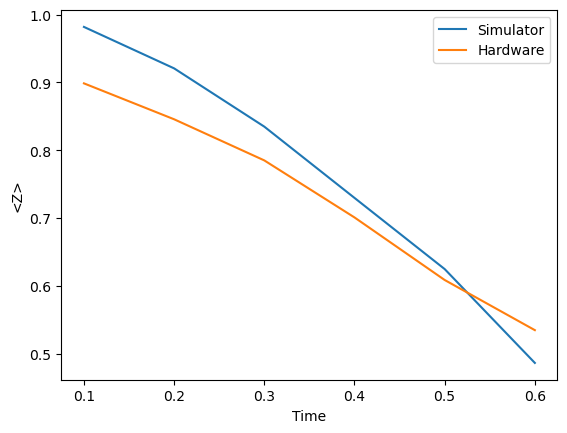

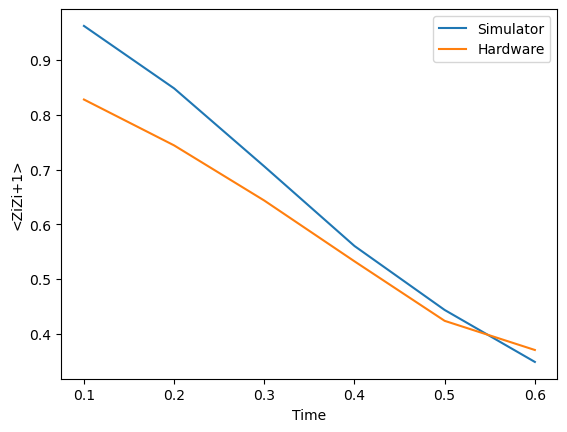

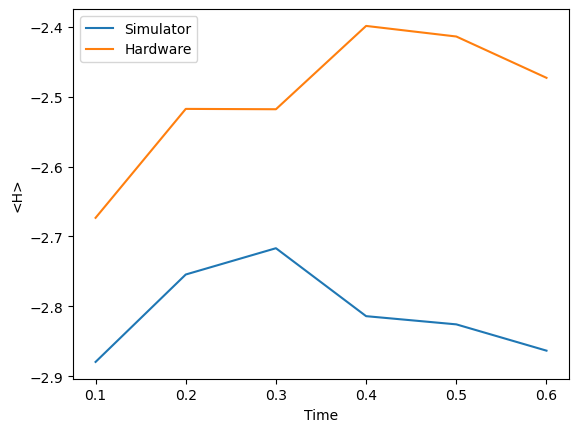

In [23]:
plt.figure()
plt.plot(times, Z_sim_vals, label="Simulator")
plt.plot(times, Z_hw_vals, label="Hardware")
plt.xlabel("Time")
plt.ylabel("<Z>")
plt.legend()
plt.show()

plt.figure()
plt.plot(times, ZZ_sim_vals, label="Simulator")
plt.plot(times, ZZ_hw_vals, label="Hardware")
plt.xlabel("Time")
plt.ylabel("<ZiZi+1>")
plt.legend()
plt.show()

plt.figure()
plt.plot(times, E_sim_vals, label="Simulator")
plt.plot(times, E_hw_vals, label="Hardware")
plt.xlabel("Time")
plt.ylabel("<H>")
plt.legend()
plt.show()